In [30]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.time import Time # can convert date to JD
import astro_models  # with pip install batman-package
from astropy import constants as c
import math

## Verify Eclipse Duration 
Determining the beginning and end phases of observations

0.47276727681455455


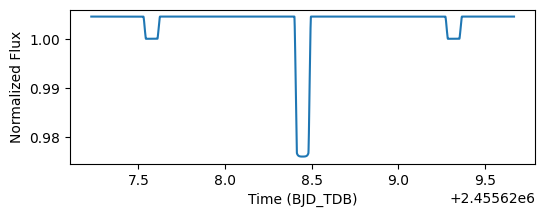

In [31]:
# from Bonomo 2017

t0   = 2455628.44758 #transit time: time at the middle of the transit, May 1st to Julian date, phase 0 = transit time
per  = 1.74299673     #Orbital period.
rp   = (1.466*c.R_jup)/(0.902*c.R_sun)#Planet radius (in units of stellar radii).
a    = (0.02810*c.au)/(0.902*c.R_sun)         #Semi-major axis (in units of stellar radii).
inc  = 88.08         #Orbital inclination (in degrees).
ecosw= 0.0           #Eccentricity multiplied by the cosine of the longitude of periastron (value between -1 and 1).
esinw= 0.0           #Eccentricity multiplied by the sine of the longitude of periastron (value between -1 and 1).
q1   = 0.01          #Limb darkening coefficient 1, parametrized to range between 0 and 1.
q2   = 0.01          #Limb darkening coefficient 2, parametrized to range between 0 and 1.
fp   = 0.0045      #Planet-to-star flux ratio. /// max-flux = 1.0045
A    = 0.0           #Amplitude of the first-order cosine term.
B    = 0.0        #Amplitude of the first-order sine term.
C    = 0.0           #(optional): Amplitude of the second-order cosine term. Default=0.
D    = 0.0           #(optional): Amplitude of the second-order sine term. Default=0.
r2   = None          #(optional): Planet radius along sub-stellar axis (in units of stellar radii). Default=None.
r2off= None          #(optional): Angle to the elongated axis with respectto the sub-stellar axis (in degrees). Default=None.

time = np.linspace(t0-0.7*per, t0+0.7*per, 10000) #Array of times at which to calculate the model.
#time = np.linspace(58782.54689555371+2400000.5, 58783.48559855371+2400000.5, 1000)
flux = astro_models.ideal_lightcurve(time, t0, per, rp, a, inc, ecosw, esinw, q1, q2, fp, A, B)

plt.figure(figsize=(6,2))
plt.plot(time,flux)
plt.xlabel('Time (BJD_TDB)')
plt.ylabel('Normalized Flux')

# start of eclipse phase 
eclip_duration = ((time[1623]-time[1234])/per)
print(0.5-eclip_duration/2)

In [32]:
P_c2  = 1.74299673
# phase of end of eclipse
R_star = 0.902*c.R_sun
a = 0.02810*c.au
theta = np.arctan(R_star/(2*a)) # angle of whole transit
# end of pre-eclipse you want to be 2 theta away, to account for ingress
tolerance = 0.005
print('end phase of pre-eclipse',0.5-(2*np.rad2deg(theta)/360).value-tolerance)
# mid pre-eclipe
print('mid phase of pre-eclipse',0.5-(2*np.rad2deg(theta)/360).value-(2.5/(1.74299673*24))-tolerance)
# start of pre-eclipe
print('start phase of pre-eclipse',0.5-(2*np.rad2deg(theta)/360).value-(5/(1.74299673*24))-tolerance)

end phase of pre-eclipse 0.47128558612067223
mid phase of pre-eclipse 0.41152261303312854
start phase of pre-eclipse 0.35175963994558485


In [33]:
# end of pre-eclipse you want to be 2 theta away, to account for ingress
print('start phase of post-eclipse',0.5+(2*np.rad2deg(theta)/360).value+tolerance)
# mid pre-eclipe
print('mid phase of post-eclipse',0.5+(2*np.rad2deg(theta)/360).value+(2.5/(1.74299673*24))+tolerance)
# start of pre-eclipe
print('end phase of post-eclipse',0.5+(2*np.rad2deg(theta)/360).value+(5/(1.74299673*24))+tolerance)

start phase of post-eclipse 0.5287144138793278
mid phase of post-eclipse 0.5884773869668715
end phase of post-eclipse 0.6482403600544152


In [34]:
# SNR
# def SNR(R_pRstar, BTp_BTstar):
#     return 
# def Td(Tstar, Rstar_a, Ab=0.3, eps=0.2):
#     return Tstar*np.sqrt(Rstar_a)*(1-Ab)**(1/4)*(2/3-(5*eps/12))**(1/4)

### PRE-ECLIPSE
Gemini South => Cerro Pachón 
midtimes = Event MidPoint Calendar
starttimes = Target Observability Start Calendar UT
endtimes = Target Observability End Calendar UT

In [35]:
def plot_windows(midt, startt, endt, airmass_pre, goodness, ncols=3):
    fig, ax = plt.subplots(ncols=ncols, nrows= math.ceil(len(airmass_pre)/ncols), figsize=(10,20), sharey=True)
    for i in range(len(airmass_pre)):
        col, row = int(i/ncols), i%ncols
        ax[col,row].axvline(startt.jd[i], lw=3, c='grey')
        ax[col,row].axvline(endt.jd[i], lw=3, c='grey')
        ax[col,row].axvspan(startt.jd[i], endt.jd[i], alpha=0.2, color='grey')
        if goodness[i]==True:
            ax[col,row].axvspan(midt.jd[i]-2.5/24, midt.jd[i]+2.5/24, alpha=0.2, color='green') # 2.5 before & after the 0.6 phase.
        else:
            ax[col,row].axvspan(midt.jd[i]-2.5/24, midt.jd[i]+2.5/24, alpha=0.1, color='red')
        ax[col,row].axvline(midt.jd[i], lw=3, c='red', ls='--')
        title = midtimes[i]+', airmass:'+str(airmass_pre[i])
        ax[col,row].set_title(title, fontsize=8)
    fig.subplots_adjust(wspace=0.1, hspace=0.5)
    return 

In [36]:
# sorted in increasing airmass
midtimes   = ['2023-04-18T09:34:00.','2023-04-25T08:54:00.','2023-05-02T08:13:00.','2023-05-09T07:33:00.','2023-05-16T06:53:00.','2023-05-23T06:12:00.','2023-07-30T05:39:00.','2023-05-30T05:32:00.','2023-07-23T06:19:00.','2023-06-06T04:52:00.','2023-07-16T07:00:00.','2023-06-13T04:11:00.','2023-07-09T07:40:00.','2023-06-20T03:31:00.','2023-07-02T08:20:00.','2023-06-27T02:51:00.','2023-06-25T09:01:00.','2023-07-04T02:10:00.','2023-06-18T09:41:00.','2023-07-11T01:30:00.','2023-06-11T10:21:00.','2023-07-18T00:50:00.','2023-07-25T00:09:00.','2023-07-31T23:29:00.']
starttimes = ['2023-04-18T05:59:00.','2023-04-25T05:32:00.','2023-05-02T05:04:00.','2023-05-09T04:37:00.','2023-05-16T04:09:00.','2023-05-23T03:42:00.','2023-07-29T23:14:00.','2023-05-30T03:14:00.','2023-07-22T23:42:00.','2023-06-06T02:46:00.','2023-07-16T00:09:00.','2023-06-13T02:19:00.','2023-07-09T00:37:00.','2023-06-20T01:51:00.','2023-07-02T01:04:00.','2023-06-27T01:24:00.','2023-06-25T01:32:00.','2023-07-04T00:56:00.','2023-06-18T01:59:00.','2023-07-11T00:29:00.','2023-06-11T02:27:00.','2023-07-18T00:01:00.','2023-07-24T23:34:00.','2023-07-31T23:06:00.']
endtimes   = ['2023-04-18T10:11:00.','2023-04-25T10:15:00.','2023-05-02T10:19:00.','2023-05-09T10:23:00.','2023-05-16T10:26:00.','2023-05-23T10:30:00.','2023-07-30T08:06:00.','2023-05-30T10:33:00.','2023-07-23T08:33:00.','2023-06-06T10:36:00.','2023-07-16T09:01:00.','2023-06-13T10:39:00.','2023-07-09T09:28:00.','2023-06-20T10:41:00.','2023-07-02T09:56:00.','2023-06-27T10:15:00.','2023-06-25T10:23:00.','2023-07-04T09:48:00.','2023-06-18T10:42:00.','2023-07-11T09:20:00.','2023-06-11T10:39:00.','2023-07-18T08:53:00.','2023-07-25T08:25:00.','2023-08-01T07:58:00.']

#corresponding airmass
airmass_pre = [1.203420,1.221020,1.243140,1.270210,1.302710,1.341300,1.355910,
               1.386790,1.403960,1.440210,1.460360,1.502890,1.526540,1.576510,
               1.604340,1.663270,1.696180,1.766060,1.805230,1.888760,1.935800,
               2.036690,2.217310,2.441390]

# Jan 18 2023, based on Bonomo+17 with new duration from batman
midtimes   = ['2023-04-11T10:03:00','2023-04-18T09:22:00','2023-04-25T08:42:00','2023-05-02T08:02:00',
              '2023-05-09T07:21:00','2023-05-16T06:41:00','2023-05-23T06:01:00','2023-05-30T05:20:00',
              '2023-06-06T04:40:00','2023-06-11T10:10:00','2023-06-13T04:00:00','2023-06-18T09:29:00',
              '2023-06-20T03:19:00','2023-06-25T08:49:00','2023-06-27T02:39:00','2023-07-02T08:09:00',
              '2023-07-04T01:59:00','2023-07-09T07:28:00','2023-07-11T01:18:00','2023-07-16T06:48:00',
              '2023-07-18T00:38:00','2023-07-23T06:08:00','2023-07-24T23:58:00','2023-07-30T05:27:00',
              '2023-07-31T23:17:00']

starttimes = ['2023-04-11T06:27:00','2023-04-18T05:59:00','2023-04-25T05:32:00','2023-05-02T05:04:00',
              '2023-05-09T04:37:00','2023-05-16T04:09:00','2023-05-23T03:42:00','2023-05-30T03:14:00',
              '2023-06-06T02:46:00','2023-06-11T02:27:00','2023-06-13T02:19:00','2023-06-18T01:59:00',
              '2023-06-20T01:51:00','2023-06-25T01:32:00','2023-06-27T01:24:00','2023-07-02T01:04:00',
              '2023-07-04T00:56:00','2023-07-09T00:37:00','2023-07-11T00:29:00','2023-07-16T00:09:00',
              '2023-07-18T00:01:00','2023-07-22T23:42:00','2023-07-24T23:34:00','2023-07-29T23:14:00',
              '2023-07-31T23:06:00']

endtimes   = ['2023-04-11T10:08:00','2023-04-18T10:11:00','2023-04-25T10:15:00','2023-05-02T10:19:00',
              '2023-05-09T10:23:00','2023-05-16T10:26:00','2023-05-23T10:30:00','2023-05-30T10:33:00',
              '2023-06-06T10:36:00','2023-06-11T10:39:00','2023-06-13T10:39:00','2023-06-18T10:41:00',
              '2023-06-20T10:41:00','2023-06-25T10:23:00','2023-06-27T10:15:00','2023-07-02T09:56:00',
              '2023-07-04T09:48:00','2023-07-09T09:28:00','2023-07-11T09:20:00','2023-07-16T09:01:00',
              '2023-07-18T08:53:00','2023-07-23T08:33:00','2023-07-25T08:25:00','2023-07-30T08:06:00',
              '2023-08-01T07:58:00']

airmass_pre = [1.202060,1.219260,1.240970,1.267580,1.299570,1.337590,1.382440,1.435110,
               1.496920,1.815850,1.569500,1.705080,1.655000,1.611850,1.756240,1.532910,
               1.877020,1.465780,2.022480,1.408570,2.199860,1.359830,2.419600,1.318400,
               2.697290]

In [41]:
midt= Time(midtimes, format='isot', scale='utc')
startt= Time(starttimes, format='isot', scale='utc')
endt= Time(endtimes, format='isot', scale='utc')

# in window
goodness = []
for i in range(len(midt)):
    if (startt[i] < midt[i]-2.4/24 and endt[i] > midt[i]+2.4/24):
        goodness.append(True)
    else: 
        goodness.append(False)
        

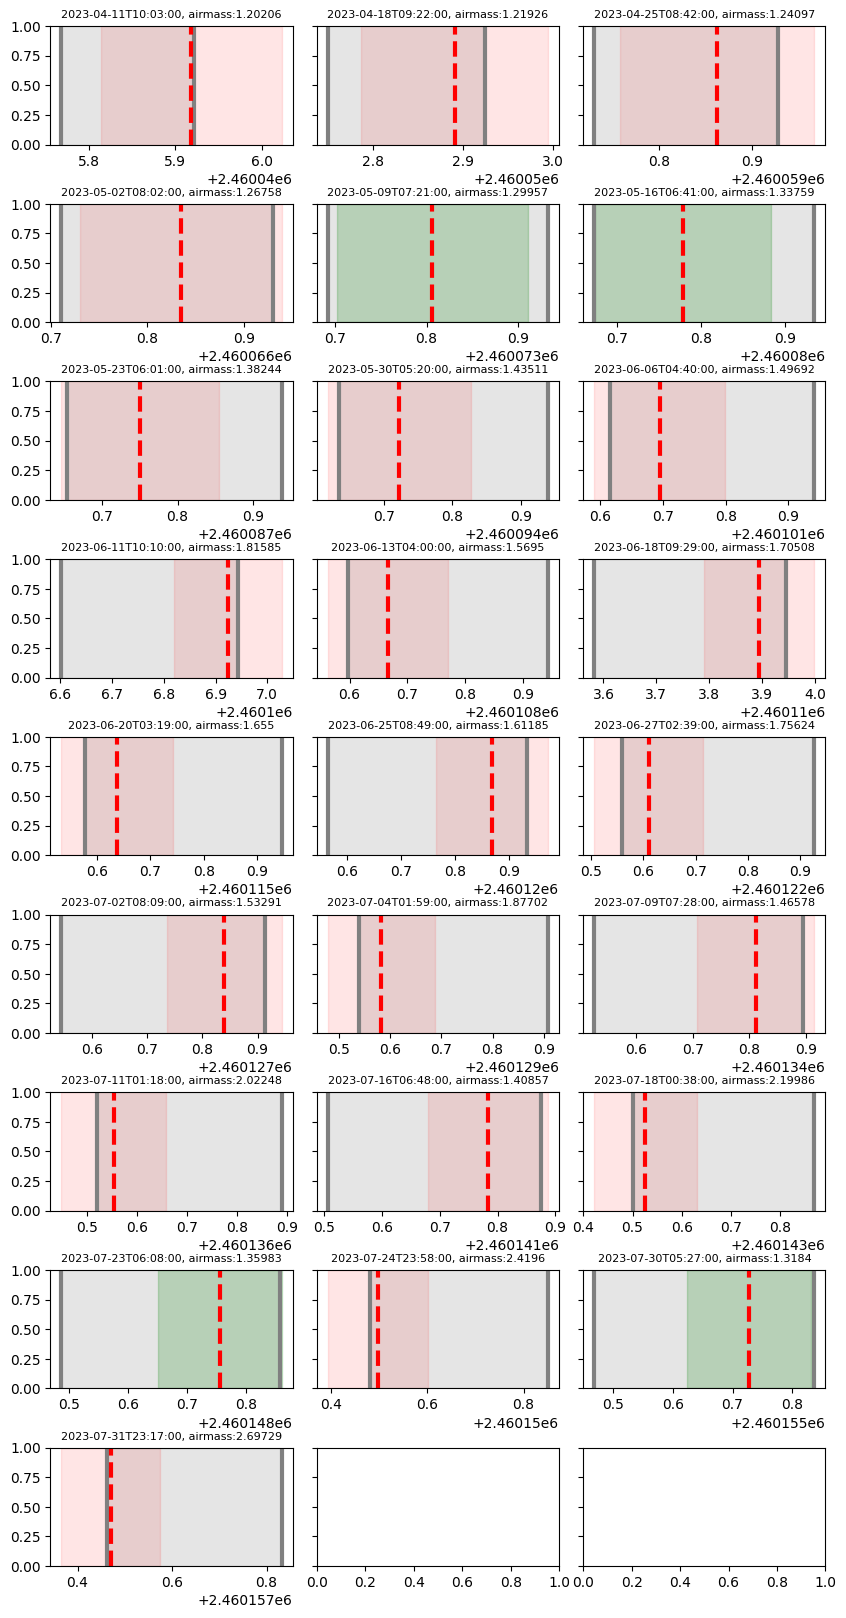

In [42]:
plot_windows(midt, startt, endt, airmass_pre, goodness)
# red dotted: NASA midpoint
# grey lines: NASA start & end point
# 5 hr completely (red shaded area) within the gray area

In [12]:
# obs 3, 4, 5 are the best, print start and end time
# print(starttimes[3]+','+endtimes[3]+', airmass:'+str(airmass_pre[3]))
# print(starttimes[4]+','+endtimes[4]+', airmass:'+str(airmass_pre[4]))
# print(starttimes[5]+','+endtimes[5]+', airmass:'+str(airmass_pre[5]))

# print all
# for i in range(len(starttimes)):
#     print(starttimes[i]+','+endtimes[i]+', airmass:'+str(airmass_pre[i])+','+str(goodness[i]))

# print windows
for i in range(len(midt)):
    if (startt[i] < midt[i]-2.5/24):
        windowstart =midt[i]-2.5/24
    else:
        windowstart =startt[i]
    if (endt[i] > midt[i]+2.5/24):
        windowend = midt[i]+2.5/24
    else: 
        windowend = endt[i]
    # window start
    a = str(windowstart.value)
    startstr = a[:10]+' '+a[11:19]
    # duration
    duration = windowend-windowstart
    durstr = '0'+str(np.floor(duration.value*24))[0]+':'+str(round(60*((duration.value*24)%1)))
    print(i, startstr, durstr, round(airmass_pre[i], 3))
    

0 2023-04-11 07:33:00 02:35 1.202
1 2023-04-18 06:52:00 03:19 1.219
2 2023-04-25 06:12:00 04:3 1.241
3 2023-05-02 05:32:00 04:47 1.268
4 2023-05-09 04:51:00 05:0 1.3
5 2023-05-16 04:11:00 05:0 1.338
6 2023-05-23 03:42:00 04:49 1.382
7 2023-05-30 03:14:00 04:36 1.435
8 2023-06-06 02:46:00 04:24 1.497
9 2023-06-11 07:40:00 02:59 1.816
10 2023-06-13 02:19:00 04:11 1.569
11 2023-06-18 06:59:00 03:42 1.705
12 2023-06-20 01:51:00 03:58 1.655
13 2023-06-25 06:19:00 04:4 1.612
14 2023-06-27 01:24:00 03:45 1.756
15 2023-07-02 05:39:00 04:17 1.533
16 2023-07-04 00:56:00 03:33 1.877
17 2023-07-09 04:58:00 04:30 1.466
18 2023-07-11 00:29:00 03:19 2.022
19 2023-07-16 04:18:00 04:43 1.409
20 2023-07-18 00:01:00 03:7 2.2
21 2023-07-23 03:38:00 04:55 1.36
22 2023-07-24 23:34:00 02:54 2.42
23 2023-07-30 02:57:00 05:0 1.318
24 2023-07-31 23:06:00 02:41 2.697


### POST ECLIPSE

In [13]:
midtimes   = ['2023-03-04T09:01','2023-04-27T09:48','2023-05-04T09:08','2023-05-11T08:27','2023-05-18T07:47','2023-05-25T07:07','2023-06-01T06:26','2023-06-08T05:46','2023-06-15T05:06','2023-06-20T10:35','2023-06-22T04:25','2023-06-27T09:55','2023-06-29T03:45','2023-07-04T09:15','2023-07-06T03:05','2023-07-11T08:34','2023-07-13T02:24','2023-07-18T07:54','2023-07-20T01:44','2023-07-25T07:14','2023-07-27T01:04',]
starttimes = ['2023-03-04T08:56','2023-04-27T05:24','2023-05-04T04:56','2023-05-11T04:29','2023-05-18T04:01','2023-05-25T03:34','2023-06-01T03:06','2023-06-08T02:39','2023-06-15T02:11','2023-06-20T01:51','2023-06-22T01:44','2023-06-27T01:24','2023-06-29T01:16','2023-07-04T00:56','2023-07-06T00:49','2023-07-11T00:29','2023-07-13T00:21','2023-07-18T00:01','2023-07-19T23:53','2023-07-24T23:34','2023-07-26T23:26',]
endtimes   = ['2023-03-04T09:43','2023-04-27T10:17','2023-05-04T10:20','2023-05-11T10:24','2023-05-18T10:28','2023-05-25T10:31','2023-06-01T10:35','2023-06-08T10:37','2023-06-15T10:40','2023-06-20T10:42','2023-06-22T10:35','2023-06-27T10:15','2023-06-29T10:08','2023-07-04T09:48','2023-07-06T09:40','2023-07-11T09:20','2023-07-13T09:12','2023-07-18T08:53','2023-07-20T08:45','2023-07-25T08:25','2023-07-27T08:17',]



#midtimes, starttimes, endtimes, airmass_post = np.array(midtimes), np.array(starttimes), np.array(endtimes), np.array(airmass_post)
#idx = np.argsort(airmass_post)
#midtimes, starttimes, endtimes, airmass_post = midtimes[idx], starttimes[idx], endtimes[idx], airmass_post[idx]

# # Jan 18 2023, based on Bonomo+17 with new duration from batman
# midtimes   = ['2023-03-04T09:09:00','2023-04-27T09:56:00','2023-05-04T09:16:00','2023-05-11T08:35:00',
#               '2023-05-18T07:55:00','2023-05-25T07:15:00','2023-06-01T06:34:00','2023-06-08T05:54:00',
#               '2023-06-15T05:14:00','2023-06-22T04:33:00','2023-06-27T10:03:00','2023-06-29T03:53:00',
#               '2023-07-04T09:23:00','2023-07-06T03:13:00','2023-07-11T08:42:00','2023-07-13T02:32:00',
#               '2023-07-18T08:02:00','2023-07-20T01:52:00','2023-07-25T07:22:00','2023-07-27T01:12:00',
#               '2023-08-01T06:41:00']

# starttimes = ['2023-03-04T08:56:00','2023-04-27T05:24:00','2023-05-04T04:56:00','2023-05-11T04:29:00',
#               '2023-05-18T04:01:00','2023-05-25T03:34:00','2023-06-01T03:06:00','2023-06-08T02:39:00',
#               '2023-06-15T02:11:00','2023-06-22T01:44:00','2023-06-27T01:24:00','2023-06-29T01:16:00',
#               '2023-07-04T00:56:00','2023-07-06T00:49:00','2023-07-11T00:29:00','2023-07-13T00:21:00',
#               '2023-07-18T00:01:00','2023-07-19T23:53:00','2023-07-24T23:34:00','2023-07-26T23:26:00',
#               '2023-07-31T23:06:00']

# endtimes   = ['2023-03-04T09:43:00','2023-04-27T10:17:00','2023-05-04T10:20:00','2023-05-11T10:24:00',
#               '2023-05-18T10:28:00','2023-05-25T10:31:00','2023-06-01T10:35:00','2023-06-08T10:37:00',
#               '2023-06-15T10:40:00','2023-06-22T10:35:00','2023-06-27T10:15:00','2023-06-29T10:08:00',
#               '2023-07-04T09:48:00','2023-07-06T09:40:00','2023-07-11T09:20:00','2023-07-13T09:12:00',
#               '2023-07-18T08:53:00','2023-07-20T08:45:00','2023-07-25T08:25:00','2023-07-27T08:17:00',
#               '2023-08-01T07:58:00']

# with midphase = 0.6 after june windows bad weather
midtimes = ['2023-03-04T09:39','2023-03-11T08:59','2023-03-18T08:19','2023-03-25T07:38','2023-05-04T09:46','2023-05-11T09:06','2023-05-18T08:26','2023-05-25T07:45','2023-06-01T07:05','2023-06-08T06:25','2023-06-15T05:44','2023-06-22T05:04','2023-06-29T04:24','2023-07-06T03:43','2023-07-11T09:13','2023-07-13T03:03','2023-07-18T08:33','2023-07-20T02:23','2023-07-25T07:52','2023-07-27T02:07','2023-08-01T07:12',]
starttimes = ['2023-03-04T08:56','2023-03-11T08:29','2023-03-18T08:01','2023-03-25T07:33','2023-05-04T04:56','2023-05-11T04:29','2023-05-18T04:01','2023-05-25T03:34','2023-06-01T03:06','2023-06-08T02:39','2023-06-15T02:11','2023-06-22T01:44','2023-06-29T01:16','2023-07-06T00:49','2023-07-11T00:29','2023-07-13T00:21','2023-07-18T00:01','2023-07-19T23:53','2023-07-24T23:34','2023-07-26T23:26','2023-07-31T23:06',]
endtimes = ['2023-03-04T09:43','2023-03-11T09:48','2023-03-18T09:53','2023-03-25T09:57','2023-05-04T10:20','2023-05-11T10:24','2023-05-18T10:28','2023-05-25T10:31','2023-06-01T10:35','2023-06-08T10:38','2023-06-15T10:40','2023-06-22T10:35','2023-06-29T10:08','2023-07-06T09:40','2023-07-11T09:20','2023-07-13T09:12','2023-07-18T08:53','2023-07-20T08:45','2023-07-25T08:25','2023-07-27T08:17','2023-08-01T07:58',]

airmass_post=[2.869190,1.173500,1.175820,1.181920,1.191900,1.205910,1.224190,1.247070,1.274950,2.784820,1.308370,2.487890,1.347990,2.254380,1.394650,2.066800,1.449440,1.913570,1.513720,1.786730,1.589250,]
airmass_post=[2.103070,2.299190,2.544320,2.857650,1.180320,1.175020,1.173490,1.175690,1.181670,1.191510,1.205390,1.223540,1.246260,1.273970,2.795730,1.307200,2.496370,1.346600,2.261120,1.308700,2.072260,]


In [14]:

midt= Time(midtimes, format='isot', scale='utc')
startt= Time(starttimes, format='isot', scale='utc')
endt= Time(endtimes, format='isot', scale='utc')

# in window
goodness = []
for i in range(len(midt)):
    if (startt[i] < midt[i]-2.4/24 and endt[i] > midt[i]+2.4/24):
        goodness.append(True)
    else: 
        goodness.append(False)
        

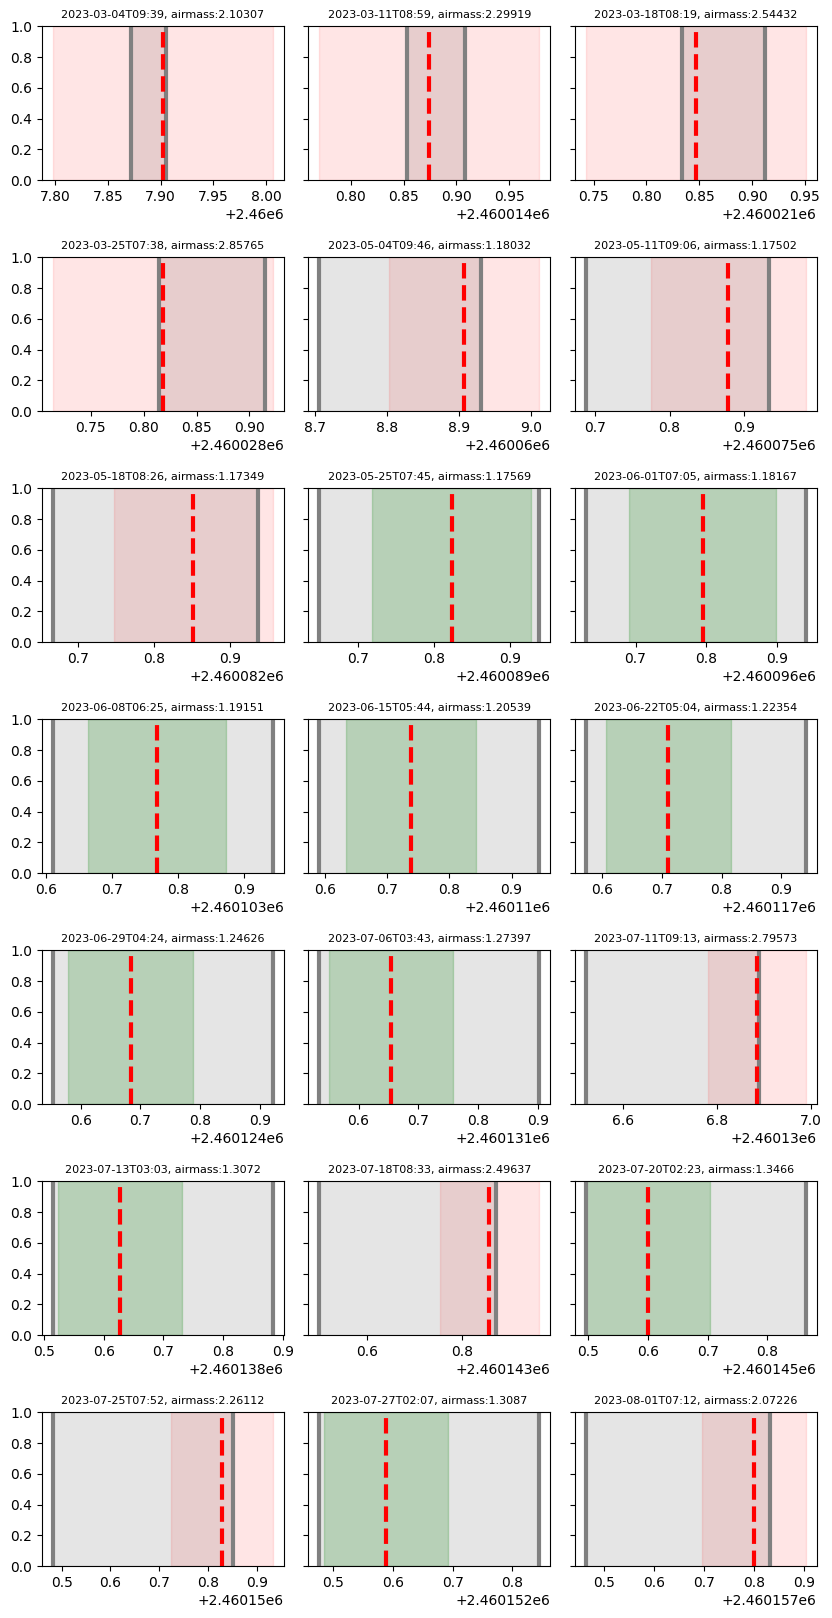

In [15]:
plot_windows(midt, startt, endt, airmass_post, goodness)

In [16]:
# obs 3, 4, 5 are the best, print start and end time
# print(starttimes[3]+','+endtimes[3]+', airmass:'+str(airmass_pre[3]))
# print(starttimes[4]+','+endtimes[4]+', airmass:'+str(airmass_pre[4]))
# print(starttimes[5]+','+endtimes[5]+', airmass:'+str(airmass_pre[5]))

# print all
# for i in range(len(starttimes)):
#     print(starttimes[i]+','+endtimes[i]+', airmass:'+str(airmass_pre[i])+','+str(goodness[i]))

# print windows
for i in range(len(midt)):
    if (startt[i] < midt[i]-2.5/24):
        windowstart =midt[i]-2.5/24
    else:
        windowstart =startt[i]
    if (endt[i] > midt[i]+2.5/24):
        windowend = midt[i]+2.5/24
    else: 
        windowend = endt[i]
    # window start
    a = str(windowstart.value)
    startstr = a[:10]+' '+a[11:19]
    # duration
    duration = windowend-windowstart
    durstr = '0'+str(np.floor(duration.value*24))[0]+':'+str(round(60*((duration.value*24)%1)))
    print(i, startstr, durstr, round(airmass_post[i], 3))

0 2023-03-04 08:56:00 00:47 2.103
1 2023-03-11 08:29:00 01:19 2.299
2 2023-03-18 08:01:00 01:52 2.544
3 2023-03-25 07:33:00 02:24 2.858
4 2023-05-04 07:16:00 03:4 1.18
5 2023-05-11 06:36:00 03:48 1.175
6 2023-05-18 05:56:00 04:32 1.173
7 2023-05-25 05:15:00 05:0 1.176
8 2023-06-01 04:35:00 05:0 1.182
9 2023-06-08 03:55:00 05:0 1.192
10 2023-06-15 03:14:00 05:0 1.205
11 2023-06-22 02:34:00 05:0 1.224
12 2023-06-29 01:54:00 05:0 1.246
13 2023-07-06 01:13:00 05:0 1.274
14 2023-07-11 06:43:00 02:37 2.796
15 2023-07-13 00:33:00 05:0 1.307
16 2023-07-18 06:03:00 02:50 2.496
17 2023-07-19 23:53:00 05:0 1.347
18 2023-07-25 05:22:00 03:3 2.261
19 2023-07-26 23:37:00 05:0 1.309
20 2023-08-01 04:42:00 03:16 2.072


In [3]:
import numpy as np
import matplotlib.pyplot as plt
time = np.linspace(0,1)
def expramp(time_local, r0, r1, r2):
    return r0*np.exp(-r1*time_local + r2)# + r3*np.exp(-r4*time_local + r5) + 1

In [22]:
ramp = expramp(time, 0.1, 100, 1)

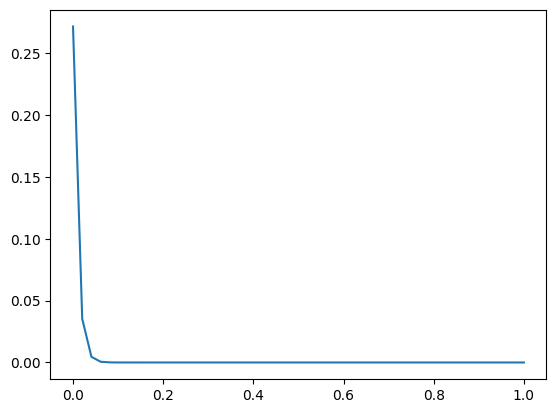

In [23]:
plt.plot(time, ramp)